# 반도체 불량(Yield) 예측 — SECOM 공정 센서 데이터 분석

**목표**: 공정 계측 센서로 웨이퍼 합불(Pass/Fail)을 예측하고, 어떤 센서가 불량에 크게 기여하는지 역추적.

**JD 연결**: 수율/데이터 분석 직무 우대사항 "데이터 시각화 및 머신러닝 분석", "통계적 공정관리(SPC) 기반 품질 데이터 분석"에 대응.

**데이터**: Kaggle SECOM — 1,567 웨이퍼 × 590 익명 센서 + 타임스탬프 + 라벨(-1 Pass / 1 Fail). Fail이 소수인 심한 클래스 불균형.

---

## 0. 환경 설정 및 데이터 로드

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'   # 한글 폰트 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', 30)
RANDOM_STATE = 42   # 재현성을 위한 난수 고정

df = pd.read_csv('uci-secom.csv')
# 원본 헤더(Time / 590개 익명센서 / Pass·Fail)를 다루기 쉬운 이름으로 표준화
df.columns = ['Time'] + [f'sensor_{i}' for i in range(df.shape[1] - 2)] + ['label']

print('shape:', df.shape)
df.head()

shape: (1567, 592)


,Time,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,...,sensor_576,sensor_577,sensor_578,sensor_579,sensor_580,sensor_581,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,label
0,2008-07-19 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,-0.0034,0.9455,202.4396,0.0,...,1.6765,14.9509,NaN,NaN,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN,-1
1,2008-07-19 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,-0.0148,0.9627,200.5470,0.0,...,1.1065,10.9003,0.0096,0.0201,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045,-1
2,2008-07-19 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,0.0013,0.9615,202.0179,0.0,...,2.0952,9.2721,0.0584,0.0484,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602,1
3,2008-07-19 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,-0.0033,0.9629,201.8482,0.0,...,1.7585,8.5831,0.0202,0.0149,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432,-1
4,2008-07-19 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,-0.0072,0.9569,201.9424,0.0,...,1.6597,10.9698,NaN,NaN,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432,-1


## 1. 데이터 탐색 (EDA)

수율 데이터의 두 가지 핵심 특성 — (1) Fail이 극소수(클래스 불균형), (2) 센서마다 결측이 많음 — 을 먼저 확인한다.

label
-1    1463
 1     104
Name: count, dtype: int64
Fail 비율: 6.637%


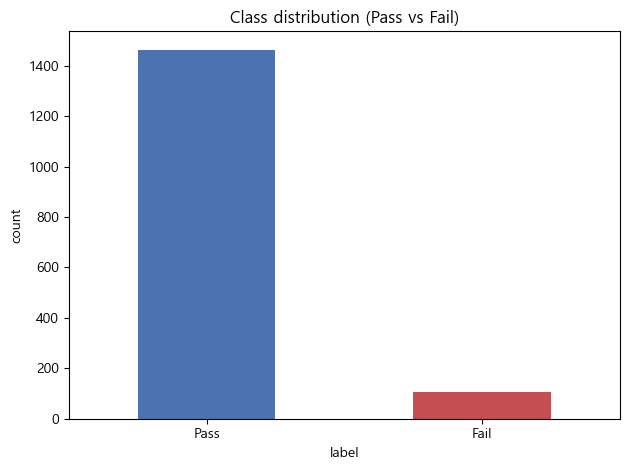

In [3]:
counts = df['label'].value_counts()
fail_rate = (df['label'] == 1).mean()   # 불량(True) 비율
print(counts)
print(f'Fail 비율: {fail_rate:.3%}')

counts.rename({-1: 'Pass', 1: 'Fail'}).plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Class distribution (Pass vs Fail)')
plt.ylabel('count'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

결측 비율 상위 10개 센서:
sensor_157    0.911934
sensor_292    0.911934
sensor_293    0.911934
sensor_158    0.911934
sensor_492    0.855775
sensor_358    0.855775
sensor_85     0.855775
sensor_220    0.855775
sensor_246    0.649649
sensor_109    0.649649
dtype: float64


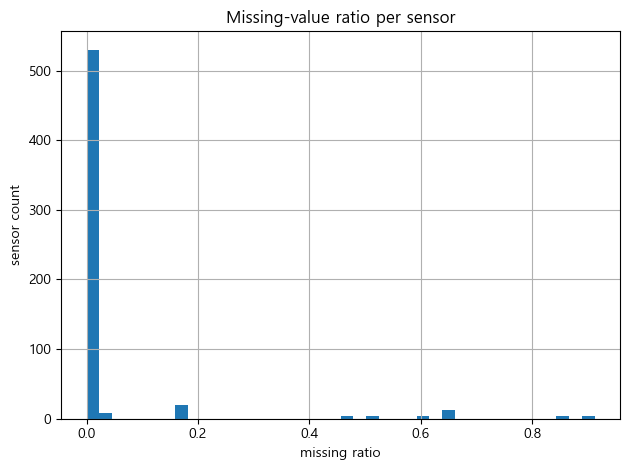

In [4]:
sensor_cols = [c for c in df.columns if c.startswith('sensor_')]
na_ratio = df[sensor_cols].isna().mean().sort_values(ascending=False)   # 센서별 결측 비율
print('결측 비율 상위 10개 센서:')
print(na_ratio.head(10))

na_ratio.hist(bins=40)
plt.title('Missing-value ratio per sensor')
plt.xlabel('missing ratio'); plt.ylabel('sensor count'); plt.tight_layout(); plt.show()
# 결측 90%+ 센서가 존재 → 전처리에서 제거 필요

### 1-1. 단변량 분리도 탐색

센서별로 (불량 평균 − 양품 평균)을 전체 표준편차 단위로 정규화한 **분리도**를 계산해, 단독으로 양품·불량을 얼마나 가르는지 눈으로 본다. (뒤의 다변량 Feature Importance와 대조용)

불량/양품 분리도 상위 10개 센서:
sensor_59     0.624373
sensor_103    0.606868
sensor_510    0.528162
sensor_348    0.519064
sensor_158    0.517005
sensor_111    0.500893
sensor_293    0.488163
sensor_431    0.487229
sensor_85     0.480197
sensor_434    0.452013
dtype: float64


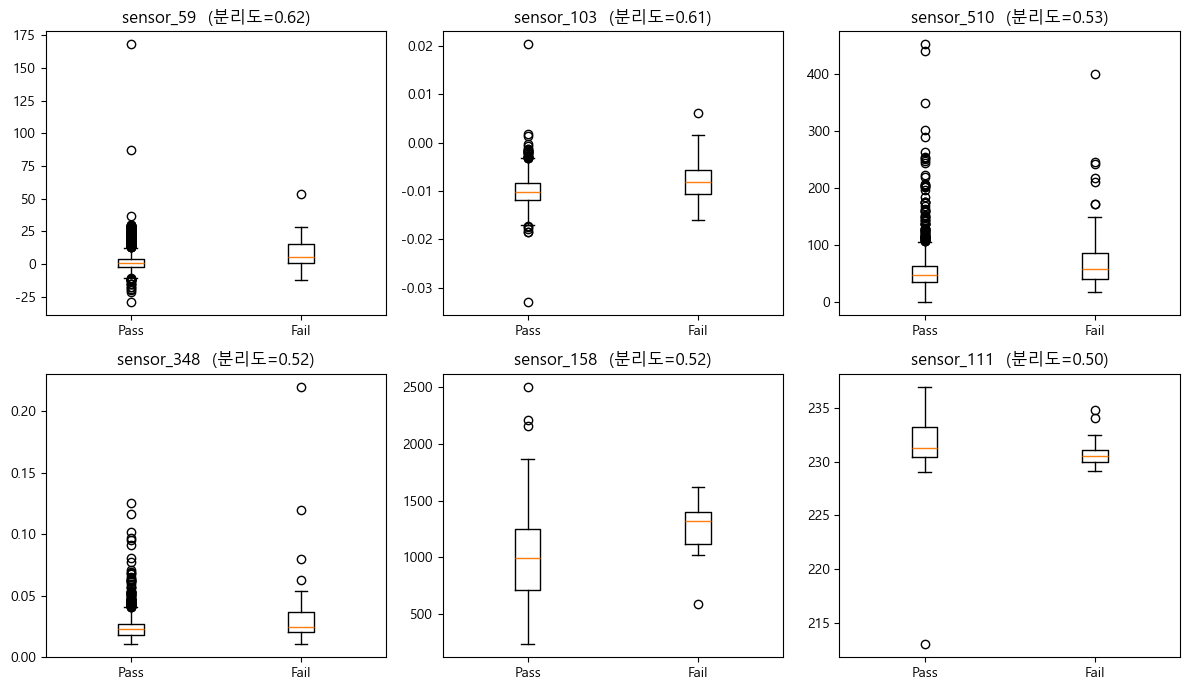

In [5]:
y = (df['label'] == 1).astype(int)   # Fail=1, Pass=0
X_all = df[sensor_cols]
pass_grp, fail_grp = X_all[y == 0], X_all[y == 1]

# 분리도 = |불량평균 - 양품평균| / 전체 표준편차
sep_score = ((fail_grp.mean() - pass_grp.mean()).abs() / X_all.std()).sort_values(ascending=False)
print('불량/양품 분리도 상위 10개 센서:')
print(sep_score.head(10))

# 상위 6개 센서의 Pass vs Fail 분포
top6 = sep_score.head(6).index
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, s in zip(axes.ravel(), top6):
    ax.boxplot([pass_grp[s].dropna(), fail_grp[s].dropna()], tick_labels=['Pass', 'Fail'])
    ax.set_title(f'{s}  (분리도={sep_score[s]:.2f})')
plt.tight_layout(); plt.show()

## 2. 전처리

- 결측 과다(>50%) 센서 제거
- 상수(분산 0) 센서 제거 — 예측 정보 없음
- 남은 결측은 중앙값 대치 (분포가 치우쳐 평균보다 중앙값이 강건)
- 표준화 (선형 모델용)
- 층화 분할 + `Pipeline`으로 데이터 누수 방지 (통계량은 학습 데이터에서만 학습)

In [6]:
from sklearn.model_selection import train_test_split

X = df[sensor_cols].copy()

# 결측 과다(>50%) 센서 제거
keep = na_ratio[na_ratio <= 0.50].index.tolist()
X = X[keep]

# 상수(분산 0) 센서 제거
nunique = X.nunique(dropna=True)
X = X[[c for c in X.columns if nunique[c] > 1]]
print('전처리 후 피처 수:', X.shape[1])

# 층화 분할: 불균형(6.6%)을 train/test 양쪽에 동일하게 유지
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print('train:', X_train.shape, '| test:', X_test.shape)
print('train fail rate:', y_train.mean().round(4), '| test fail rate:', y_test.mean().round(4))

전처리 후 피처 수: 446
train: (1175, 446) | test: (392, 446)
train fail rate: 0.0664 | test fail rate: 0.0663


## 3. 모델링 — 불균형을 고려한 평가 설계

Fail이 6.6%뿐이라 전부 Pass로 찍어도 정확도 93%가 나온다 → **정확도는 무의미**. 대신 **Recall**(불량 놓치지 않기)과 **ROC-AUC**(전체 판별력)로 평가한다.

- Baseline: Logistic Regression (`class_weight='balanced'`)
- 주력: Random Forest — 비선형·상호작용 포착, Feature Importance 제공

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay)

# Baseline: median 대치 → 표준화 → 선형 분류
# class_weight='balanced': 불량 6.6% → 소수 클래스 가중
logit = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
])
logit.fit(X_train, y_train)
p_logit = logit.predict_proba(X_test)[:, 1]   # 불량(1) 확률

print('[LogReg] ROC-AUC:', round(roc_auc_score(y_test, p_logit), 4))
print(classification_report(y_test, logit.predict(X_test), target_names=['Pass', 'Fail']))

[LogReg] ROC-AUC: 0.6694
              precision    recall  f1-score   support

        Pass       0.94      0.88      0.91       366
        Fail       0.10      0.19      0.13        26

    accuracy                           0.83       392
   macro avg       0.52      0.54      0.52       392
weighted avg       0.88      0.83      0.86       392



> **ROC-AUC 읽는 법**: 불량 확률에 대한 판정 기준선(임계값)을 0→1로 옮기며 재현율(y축)과 거짓경보율(x축)을 그린 곡선의 아래 넓이. 0.5=찍기, 1.0=완벽. 임계값과 무관한 '순위 능력'이라 불균형에 덜 속는다.

결과: LogReg는 accuracy 0.83으로 보이지만 Fail recall 0.19에 불과 — 정확도의 함정을 실증.

In [8]:
# 주력: Random Forest (400 trees) — 트리 분할이라 스케일링 불필요
rf = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(n_estimators=400, class_weight='balanced',
                                   n_jobs=-1, random_state=RANDOM_STATE))
])
rf.fit(X_train, y_train)
p_rf = rf.predict_proba(X_test)[:, 1]

print('[RandomForest] ROC-AUC:', round(roc_auc_score(y_test, p_rf), 4))
print(classification_report(y_test, rf.predict(X_test), target_names=['Pass', 'Fail'], zero_division=0))

cm = confusion_matrix(y_test, rf.predict(X_test))
print('Confusion matrix [[TN FP] [FN TP]]:')
print(cm)

[RandomForest] ROC-AUC: 0.7983
              precision    recall  f1-score   support

        Pass       0.93      1.00      0.97       366
        Fail       0.00      0.00      0.00        26

    accuracy                           0.93       392
   macro avg       0.47      0.50      0.48       392
weighted avg       0.87      0.93      0.90       392

Confusion matrix [[TN FP] [FN TP]]:
[[366   0]
 [ 26   0]]


**Confusion matrix 읽는 법**

|  | 예측 양품 | 예측 불량 |
|---|---|---|
| **실제 양품** | TN | FP (헛발질) |
| **실제 불량** | FN (놓침) | TP |

- **FN** = 실제 불량인데 양품이라 판정 (놓침, 소비자 위험)
- **FP** = 실제 양품인데 불량이라 판정 (헛발질, 생산자 위험)
- recall = TP/(TP+FN), precision = TP/(TP+FP)

결과: RF는 AUC 0.80으로 순위 능력은 좋지만, 기본 임계값 0.5에선 전부 양품 예측(recall 0). → 모델이 아니라 **임계값이 문제**.

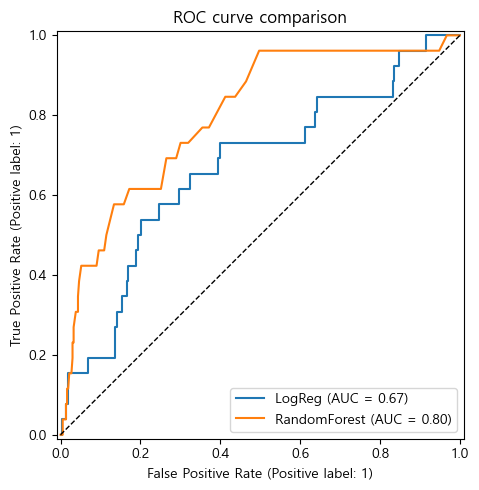

In [9]:
# 두 모델 ROC 곡선 비교
fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(y_test, p_logit, name='LogReg', ax=ax)
RocCurveDisplay.from_predictions(y_test, p_rf, name='RandomForest', ax=ax)
ax.plot([0, 1], [0, 1], 'k--', lw=1)   # 대각선 = 찍기(AUC 0.5)
ax.set_title('ROC curve comparison'); plt.tight_layout(); plt.show()

### 3-1. 임계값(Threshold) 조정

기본 0.5는 불균형에서 Fail을 대부분 놓친다. **불량 유출 비용 vs 과검 비용**의 균형점을 찾아 임계값을 낮춘다.

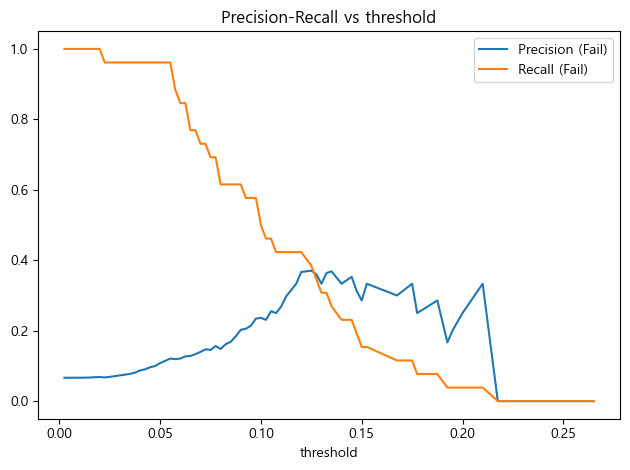

threshold=0.090 에서 Recall=0.62, Precision=0.20


In [10]:
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, p_rf)
plt.plot(thr, prec[:-1], label='Precision (Fail)')   # prec/rec는 thr보다 1개 많아 [:-1]
plt.plot(thr, rec[:-1], label='Recall (Fail)')
plt.xlabel('threshold'); plt.legend(); plt.title('Precision-Recall vs threshold')
plt.tight_layout(); plt.show()

# 목표 재현율(60%)을 만족하는 임계값 중 정밀도가 가장 좋은 지점
target_recall = 0.60
idx = np.where(rec[:-1] >= target_recall)[0]
if len(idx):
    j = idx[-1]   # 임계값 오름차순 → 마지막이 재현율 조건 만족 중 최고 정밀도
    print(f'threshold={thr[j]:.3f} 에서 Recall={rec[j]:.2f}, Precision={prec[j]:.2f}')

## 4. Feature Importance 역추적

Random Forest의 중요도로 **불량과 강하게 연관된 상위 센서**를 뽑는다 (수율 엔지니어의 원인 규명 과정).

sensor_59     0.015819
sensor_103    0.013468
sensor_33     0.012053
sensor_247    0.009011
sensor_510    0.008796
sensor_130    0.008510
sensor_64     0.007371
sensor_31     0.007276
sensor_205    0.007001
sensor_213    0.006849
sensor_129    0.006482
sensor_477    0.006071
sensor_341    0.006009
sensor_351    0.005908
sensor_21     0.005870
dtype: float64


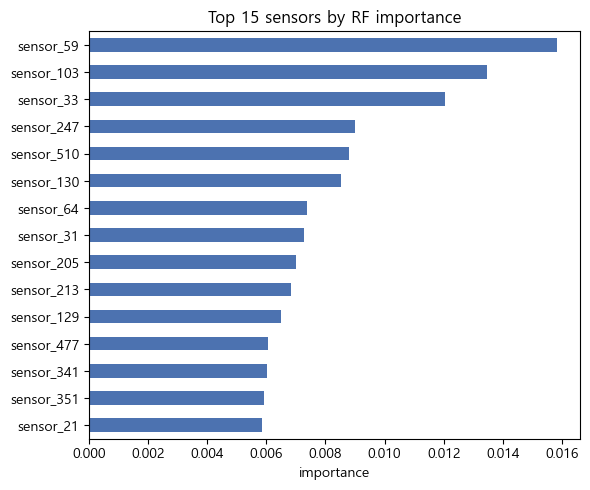

In [11]:
# clf 단계(RF)의 feature_importances_ → 센서 이름과 매핑 후 정렬
importances = pd.Series(
    rf.named_steps['clf'].feature_importances_, index=X_train.columns
).sort_values(ascending=False)

print(importances.head(15))

importances.head(15)[::-1].plot(kind='barh', figsize=(6, 5), color='#4C72B0')   # [::-1]: 큰 값이 맨 위로
plt.title('Top 15 sensors by RF importance')
plt.xlabel('importance'); plt.tight_layout(); plt.show()

## 5. 품질 관점 연결 — SPC 관리도

중요도 1위 센서를 평균 ±3σ 관리한계선과 함께 그려, 불량 샘플이 관리한계를 벗어나는지(OOC) 확인한다. 머신러닝 결과를 품질 엔지니어의 언어(관리도)로 번역하는 작업.

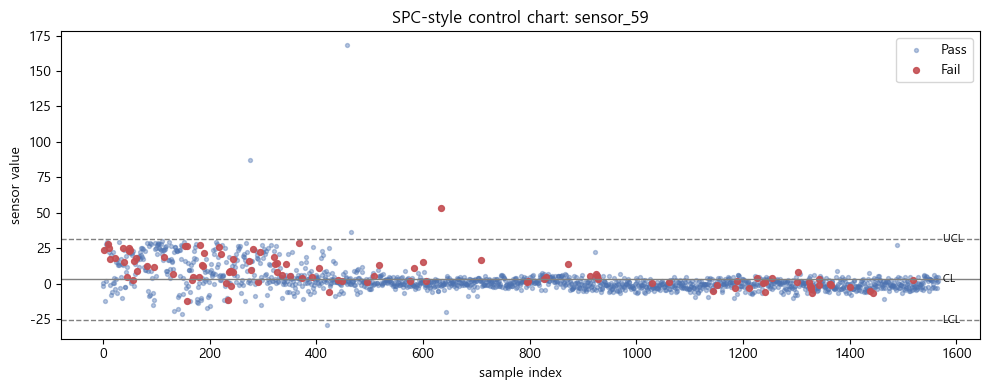

전체 Fail 비율: 6.637%
sensor_59 OOC 샘플의 Fail 비율: 20.000% (n=5)


In [12]:
top_sensor = importances.index[0]
s = df[top_sensor]
mu, sigma = s.mean(), s.std()
ucl, lcl = mu + 3 * sigma, mu - 3 * sigma

fig, ax = plt.subplots(figsize=(10, 4))
idx = np.arange(len(s))
mask_fail = (df['label'] == 1).values
ax.scatter(idx[~mask_fail], s[~mask_fail], s=8, alpha=0.4, label='Pass', color='#4C72B0')
ax.scatter(idx[mask_fail], s[mask_fail], s=18, alpha=0.9, label='Fail', color='#C44E52')
for yv, ls, lab in [(mu, '-', 'CL'), (ucl, '--', 'UCL'), (lcl, '--', 'LCL')]:
    ax.axhline(yv, color='gray', linestyle=ls, lw=1)
    ax.text(len(s), yv, f' {lab}', va='center', fontsize=8)
ax.set_title(f'SPC-style control chart: {top_sensor}')
ax.set_xlabel('sample index'); ax.set_ylabel('sensor value'); ax.legend()
plt.tight_layout(); plt.show()

# 관리한계 이탈(OOC) 샘플의 Fail 비율 vs 전체 Fail 비율
ooc = (s > ucl) | (s < lcl)
print(f'전체 Fail 비율: {mask_fail.mean():.3%}')
if ooc.sum() > 0:
    print(f'{top_sensor} OOC 샘플의 Fail 비율: {df.loc[ooc, "label"].eq(1).mean():.3%} (n={int(ooc.sum())})')

## 6. 결론 및 한계

**요약**
- 590개 익명 센서 → 결측/상수 제거 후 446개로 줄임.
- Random Forest ROC-AUC ≈ 0.80. 기본 임계값 0.5에선 Fail recall 0 → 임계값 0.09로 조정 시 recall ≈ 0.62(정밀도 0.20).
- 불량 연관 상위 센서: sensor_59·103·33. 단 중요도가 낮고 평탄 → 단일 원인 센서 없음(다변량 상호작용).

**한계**
1. 센서 익명화로 물리적 원인 해석 불가 → 상위 센서는 후속 추적 대상으로만.
2. 클래스 불균형이 심해 Precision이 낮음 → 자동 판정용이 아니라 선별(스크리닝) 보조.

**배운 점**
- 수율 데이터에서 중요한건 불균형과 결측이며, 정확도가 아니라 Recall·AUC·임계값 설계가 핵심.
- 머신러닝 결과를 SPC 관리도로 확인해 품질/공정과 연결.

---
*데이터: UCI SECOM Dataset (McCann & Johnston, 2008).*